In [7]:
import pandas as pd
import numpy as np
import os
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.getcwd()), print(os.listdir('/content/drive/MyDrive'))

In [ ]:
dataframes = []

path = '../data'
files = glob.glob(os.path.join(path, '*.csv'))
print(len(files))

# READ FILES
for f in files:

    # READ CONTENT USING PANDAS
    temp_file = pd.read_csv(f, skiprows=3)

    # EXTRACT CAPACITY
    basename = os.path.basename(f).replace('.csv', '')

    match = re.search(r'^(\d+)2[0-4][bwty]*$', basename)

    capacity = int(match.group(1)) if match else 0

    # INSERT CAPACITY_KW COLUMN
    temp_file.insert(1, 'capacity (kW)', int(capacity))

    # DROP LOCAL TIME
    temp_file = temp_file.drop('local_time', axis=1)

    # CONVERT TIME TO PROPER DATETIME
    temp_file['time'] = pd.to_datetime(temp_file['time'])

    # RENAME ELECTRICITY COL TO GENERATION
    temp_file.rename(columns={'electricity':'generation (kW)'}, inplace=True)

    # APPEND TO DATAFRAMES
    dataframes.append(temp_file)

print(len(dataframes))

combine_data = pd.concat(dataframes, ignore_index=True)
print(len(combine_data))
print(combine_data.tail()), print(combine_data.dtypes)

In [ ]:
combine_data.to_csv('../data/new_data/Renergy.csv', index=False)

In [9]:
ds = pd.read_csv('/content/drive/MyDrive/data/Renergy.csv', index_col=False)

ds.dtypes

,0
time,object
capacity (kW),int64
generation (kW),float64
irradiance_direct,float64
irradiance_diffuse,float64
temperature,float64


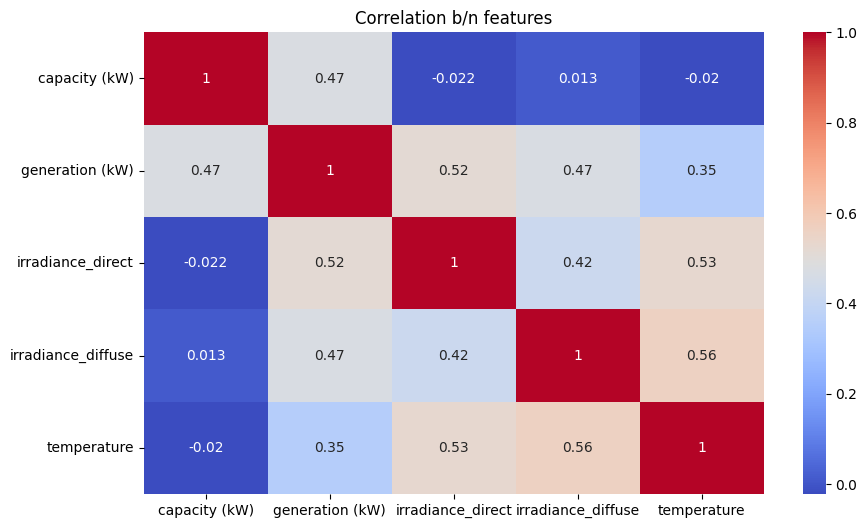

In [10]:
plt.figure(figsize=(10, 6))
sns.heatmap(ds.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation b/n features')
plt.show()

In [ ]:
plot_data = ds.drop(['time'], axis=1)

plt.figure(figsize=(15, 4))
plt.subplot(1, 2, 1)
sns.barplot(x=plot_data['capactiy (kW)'], y=plot_data['generation (kW)'], hue=plot_data['capacity (kW)'], data=plot_data, palette='viridis')
plt.title('plot of features')

plt.subplot(1, 2, 2)
sns.barplot(x=plot_data['temperature'], y=plot_data['generation (kW)'], data=plot_data[:24], hue=plot_data['temperature'], palette='viridis')

plt.tight_layout()
plt.show()

In [21]:
print(list(ds.columns))
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

print(ds.head())

['time', 'capacity (kW)', 'generation (kW)', 'irradiance_direct', 'irradiance_diffuse', 'temperature', 'hour', 'month', 'dayofyear', 'dayofweek', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'dayofweek_sin', 'dayofweek_cos', 'isdaylight', 'gen_lag1', 'gen_lag24']
                 time  capacity (kW)  generation (kW)  irradiance_direct  \
0 2021-01-01 00:00:00         100000              0.0                0.0   
1 2021-01-01 01:00:00         100000              0.0                0.0   
2 2021-01-01 02:00:00         100000              0.0                0.0   
3 2021-01-01 03:00:00         100000              0.0                0.0   
4 2021-01-01 04:00:00         100000              0.0                0.0   

   irradiance_diffuse  temperature  hour  month  dayofyear  dayofweek  ...  \
0                 0.0       26.482     0      1          1          4  ...   
1                 0.0       25.664     1      1          1          4  ...   
2     

In [22]:
ds['time'] = pd.to_datetime(ds['time'])

ds['hour'] = ds['time'].dt.hour
ds['month'] = ds['time'].dt.month
ds['dayofyear'] = ds['time'].dt.dayofyear
ds['dayofweek'] = ds['time'].dt.dayofweek


ds['hour_sin'], ds['hour_cos'] = np.sin(2*np.pi * ds['hour']/24), np.cos(2*np.pi*ds['hour']/24)
ds['month_sin'], ds['month_cos'] = np.sin(2*np.pi*ds['month']/12), np.cos(2*np.pi*ds['month']/12)
ds['dayofyear_sin'], ds['dayofyear_cos'] = np.sin(2*np.pi*ds['dayofyear']/365), np.cos(2*np.pi*ds['dayofyear']/365)
ds['dayofweek_sin'], ds['dayofweek_cos'] = np.sin(2*np.pi*ds['dayofweek']/7), np.cos(2*np.pi*ds['dayofweek']/7)

ds['isdaylight'] = ds['hour'].apply(lambda x: 1 if 6<=x>=18 else 0)

ds['gen_lag1'] = ds['generation (kW)'].shift(1)
ds['gen_lag24'] = ds['generation (kW)'].shift(24)

dst = ds.drop(['time', 'hour', 'month', 'dayofyear', 'dayofweek'], axis=1)
dst.dropna(inplace=True)
print(dst.head())



    capacity (kW)  generation (kW)  irradiance_direct  irradiance_diffuse  \
24         100000              0.0                0.0                 0.0   
25         100000              0.0                0.0                 0.0   
26         100000              0.0                0.0                 0.0   
27         100000              0.0                0.0                 0.0   
28         100000              0.0                0.0                 0.0   

    temperature  hour_sin  hour_cos  month_sin  month_cos  dayofyear_sin  \
24       24.461  0.000000  1.000000        0.5   0.866025       0.034422   
25       23.813  0.258819  0.965926        0.5   0.866025       0.034422   
26       23.127  0.500000  0.866025        0.5   0.866025       0.034422   
27       22.407  0.707107  0.707107        0.5   0.866025       0.034422   
28       21.711  0.866025  0.500000        0.5   0.866025       0.034422   

    dayofyear_cos  dayofweek_sin  dayofweek_cos  isdaylight  gen_lag1  \
24     

In [8]:
print(list(dst.columns))

['capacity (kW)', 'generation (kW)', 'irradiance_direct', 'irradiance_diffuse', 'temperature', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'dayofweek_sin', 'dayofweek_cos', 'isdaylight']


In [23]:
features = [
    'temperature',
    'capacity (kW)',
    'irradiance_direct',
    'irradiance_diffuse',
    'irradiance_direct',
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos',
    'dayofweek_sin',
    'dayofweek_cos',
    'dayofyear_sin',
    'dayofyear_cos',
    'isdaylight',
    'gen_lag1',
    'gen_lag24'
]

X = dst[features].astype('Float32')
y = dst['generation (kW)'].astype('float32')

index = int(len(ds)*0.8)

X_train, X_test = X[:index], X[index:]
y_train, y_test = y[:index], y[index:]

print(list(X.columns))
print(len(y)), print(len(y_train)), print(len(y_test)), print(len(X_train)), print(len(X_test))

['temperature', 'capacity (kW)', 'irradiance_direct', 'irradiance_diffuse', 'irradiance_direct', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos', 'dayofyear_sin', 'dayofyear_cos', 'isdaylight', 'gen_lag1', 'gen_lag24']
648816
519072
129744
519072
129744


(None, None, None, None, None)

In [24]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:

params_config = {
    'model1': {'n_estimators': [100, 200], 
           'max_depth': [10, 15, None], 
           'criterion': ['squared_error', 'friedman_mse', 'poisson'], 
           'max_features': ['sqrt', 'log2']
           },
    'model2': {'hidden_layer_sizes': [(100,), (100, 50), (50, 25)],
            'alpha': [0.0001, 0.05],
            'activation': ['relu', 'tanh'],
            'learning_rate_init': [0.001, 0.01]
            },
    'model3': {
            'n_estimators': [100, 300],
            'learning_rate': [0.05, 0.1],
            'max_depth': [6, 10, 15],
            'subsample': [0.8, 1.0]
            }
}

basemodels = {'model1': RandomForestRegressor(), 
              'model2': MLPRegressor(max_iter=200), 
              'model3': XGBRegressor(n_jobs=1)
}

def best_param_grid_search(models, all_params, X, y):
    best_params_results = {}

    for name, model in models.items():

        params = all_params[name]

        search = GridSearchCV(estimator=model, param_grid=params, cv=5, n_jobs=-1)
        search.fit(X, y)
        
        print(f'{name}: {search.best_params_}')

        best_params_results[name] = search.best_params_

    return best_params_results

X_sample, _, y_sample, _ = train_test_split(X_train_scaled, y_train, train_size=1500, random_state=42)

best_params = best_param_grid_search(basemodels, params_config, X_sample, y_sample)